In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> project root
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd

from src.config import (
    PROJECT_ROOT as CONFIG_PROJECT_ROOT,
    DATA_RAW_DIR,
    GEO_LIST_36,
    DATA_INTERIM_DIR,
)

from src.data.load_raw import (
    loadHicpIndex,
    loadHicpInflation,
    loadIncomeQuantiles,
    loadEmploymentIndex,
    loadGeoLabels,
    loadCoicopLabels,
)

from src.data.transform_raw import (
    makeHicpIndexLong,
    makeHicpInflationLong,
    makeIncomeQuantilesLong,
    makeEmploymentIndexLong,
    makeHicpIndexQuarterly,
    makeHicpInflationQuarterly,
    makeIncomeQuarterly,
    makeEmploymentQuarterly,
)




PROJECT_ROOT, CONFIG_PROJECT_ROOT, DATA_RAW_DIR, len(GEO_LIST_36)


(PosixPath('/Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income'),
 PosixPath('/Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income'),
 PosixPath('/Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/data_raw'),
 36)

In [2]:
geo = loadGeoLabels()
coicop = loadCoicopLabels()

hicp_index = loadHicpIndex()
hicp_inflation = loadHicpInflation()

print("Geo labels:")
display(geo)

print("COICOP labels:")
display(coicop)


Geo labels:


,geo,geo_label
0,AT,Austria
1,BE,Belgium
2,BG,Bulgaria
3,CH,Switzerland
4,CY,Cyprus
5,CZ,Czechia
6,DE,Germany
7,DK,Denmark
8,EA,Euro area (changing composition)
9,EA19,Euro area - 19 countries (2015-2022)


COICOP labels:


,coicop,coicop_label
0,CP00,All-items HICP
1,CP01,Food and non-alcoholic beverages
2,CP02,"Alcoholic beverages, tobacco and narcotics"
3,CP03,Clothing and footwear
4,CP04,"Housing, water, electricity, gas and other fuels"
5,CP05,"Furnishings, household equipment and routine h..."
6,CP06,Health
7,CP07,Transport
8,CP08,Communications
9,CP09,Recreation and culture


In [3]:
hicp_index_long = makeHicpIndexLong(loadHicpIndex())
hicp_inflation_long = makeHicpInflationLong(loadHicpInflation())
income_long = makeIncomeQuantilesLong(loadIncomeQuantiles())
employment_long = makeEmploymentIndexLong(loadEmploymentIndex())

print("HICP index long:", hicp_index_long.shape)
print("HICP inflation long:", hicp_inflation_long.shape)
print("Income long:", income_long.shape)
print("Employment long:", employment_long.shape)

HICP index long: (145548, 7)
HICP inflation long: (145548, 7)
Income long: (48384, 8)
Employment long: (43200, 9)


In [4]:
# Checking datatypes
print("\n Index Datatypes \n")
print(hicp_index_long.dtypes)
print("\n Inflation Datatypes \n")
print(hicp_inflation_long.dtypes)
print("\n Income Datatypes \n")
print(income_long.dtypes)
print("\n Employment Datatypes \n")
print(employment_long.dtypes)


 Index Datatypes 

freq            object
unit            object
coicop          object
geo             object
timeStr         object
hicpIndex      Float64
timeMonth    period[M]
dtype: object

 Inflation Datatypes 

freq                object
unit                object
coicop              object
geo                 object
timeStr             object
hicpInflation      Float64
timeMonth        period[M]
dtype: object

 Income Datatypes 

freq                  object
quantile              object
indic_il              object
currency              object
geo                   object
timeStr               object
incomeValue          Float64
timeYear       period[Y-DEC]
dtype: object

 Employment Datatypes 

freq                      object
unit                      object
nace_r2                   object
s_adj                     object
na_item                   object
geo                       object
timeStr                   object
employmentIndex          Float64
timeQuarter        per

In [5]:
hicp_index_long.head()

,freq,unit,coicop,geo,timeStr,hicpIndex,timeMonth
0,M,I15,CP00,AT,2000-01,74.28,2000-01
1,M,I15,CP00,BE,2000-01,72.66,2000-01
2,M,I15,CP00,BG,2000-01,52.49,2000-01
3,M,I15,CP00,CH,2000-01,<NA>,2000-01
4,M,I15,CP00,CY,2000-01,73.63,2000-01


In [6]:
hicp_inflation_long.head()

,freq,unit,coicop,geo,timeStr,hicpInflation,timeMonth
0,M,RCH_A,CP00,AT,2000-01,1.4,2000-01
1,M,RCH_A,CP00,BE,2000-01,0.3,2000-01
2,M,RCH_A,CP00,BG,2000-01,7.0,2000-01
3,M,RCH_A,CP00,CH,2000-01,<NA>,2000-01
4,M,RCH_A,CP00,CY,2000-01,4.4,2000-01


In [7]:
income_long.head()

,freq,quantile,indic_il,currency,geo,timeStr,incomeValue,timeYear
0,A,D1,SHARE,EUR,AT,2000,4.0,2000
1,A,D1,SHARE,EUR,BE,2000,4.0,2000
2,A,D1,SHARE,EUR,BG,2000,<NA>,2000
3,A,D1,SHARE,EUR,CH,2000,<NA>,2000
4,A,D1,SHARE,EUR,CY,2000,<NA>,2000


In [8]:
employment_long.head()

,freq,unit,nace_r2,s_adj,na_item,geo,timeStr,employmentIndex,timeQuarter
0,Q,I15_HW,A,SCA,EMP_DC,AT,2000-Q1,158.7,2000Q1
1,Q,I15_HW,A,SCA,EMP_DC,BE,2000-Q1,104.6,2000Q1
2,Q,I15_HW,A,SCA,EMP_DC,BG,2000-Q1,115.7,2000Q1
3,Q,I15_HW,A,SCA,EMP_DC,CH,2000-Q1,107.8,2000Q1
4,Q,I15_HW,A,SCA,EMP_DC,CY,2000-Q1,141.3,2000Q1


### Checking working of Data Frequency Conversion

- I have created below 4 checks to make sure that conversion of data which is monthly---> Quater and annual----> Quater is done properly alongside within specific range 2000-2024 by functions in transform_raw.py

- To make sure all edges cases are handled properly such as:

1. Correct quarter mapping: yes, via pandas Period + Q-DEC.

2. No mixing across years: quarter includes year; grouping is by quarter.

3. Drop 2025+ and pre-2000: yes, via explicit valid_quarters filter.

4. Flags (b, p, e…) removed: yes, via regex numeric extraction.

5. Missing annual values → all four quarters NaN: yes, replication keeps NaN.

6. Information about incomplete quarters preserved: nMonths column.

In [9]:
# Calling frequency alignment functions (Quaterly data frequency)

hicp_index_q = makeHicpIndexQuarterly(hicp_index_long)
hicp_inflation_q = makeHicpInflationQuarterly(hicp_inflation_long)
income_q = makeIncomeQuarterly(income_long)
employment_q = makeEmploymentQuarterly(employment_long)

print("HICP index quarterly:", hicp_index_q.shape)
print("HICP inflation quarterly:", hicp_inflation_q.shape)
print("Income quarterly:", income_q.shape)
print("Employment quarterly:", employment_q.shape)

hicp_index_q.head()



HICP index quarterly: (46800, 7)
HICP inflation quarterly: (46800, 7)
Income quarterly: (193536, 9)
Employment quarterly: (43200, 9)


,freq,unit,coicop,geo,timeQuarter,hicpIndex,nMonths
0,M,I15,CP00,AT,2000Q1,74.683333,3
1,M,I15,CP00,AT,2000Q2,74.83,3
2,M,I15,CP00,AT,2000Q3,74.923333,3
3,M,I15,CP00,AT,2000Q4,75.64,3
4,M,I15,CP00,AT,2001Q1,76.166667,3


In [10]:
#  Check 1 | the time range and counts | Unique quarters present
for name, df in [
    ("HICP index", hicp_index_q),
    ("HICP inflation", hicp_inflation_q),
    ("Income", income_q),
    ("Employment", employment_q),
]:
    quarters = df["timeQuarter"].sort_values().unique()
    print(
        f"{name}: first quarter = {quarters[0]}, "
        f"last quarter = {quarters[-1]}, "
        f"n_quarters = {len(quarters)}"
    )


HICP index: first quarter = 2000Q1, last quarter = 2024Q4, n_quarters = 100
HICP inflation: first quarter = 2000Q1, last quarter = 2024Q4, n_quarters = 100
Income: first quarter = 2000Q1, last quarter = 2024Q4, n_quarters = 96
Employment: first quarter = 2000Q1, last quarter = 2024Q4, n_quarters = 100


- On cross-checking with source on Eurostat the income data for year 2002 does not exist, but it's better to have year 2002 for continuity and uniformity.

- So we will later add year 2002 rows with NaN values so that we don't add bias but at the same time keep continuity and uniformity.

- Thus we will have 100 quarters among all 4 datasets for the merged dataset.

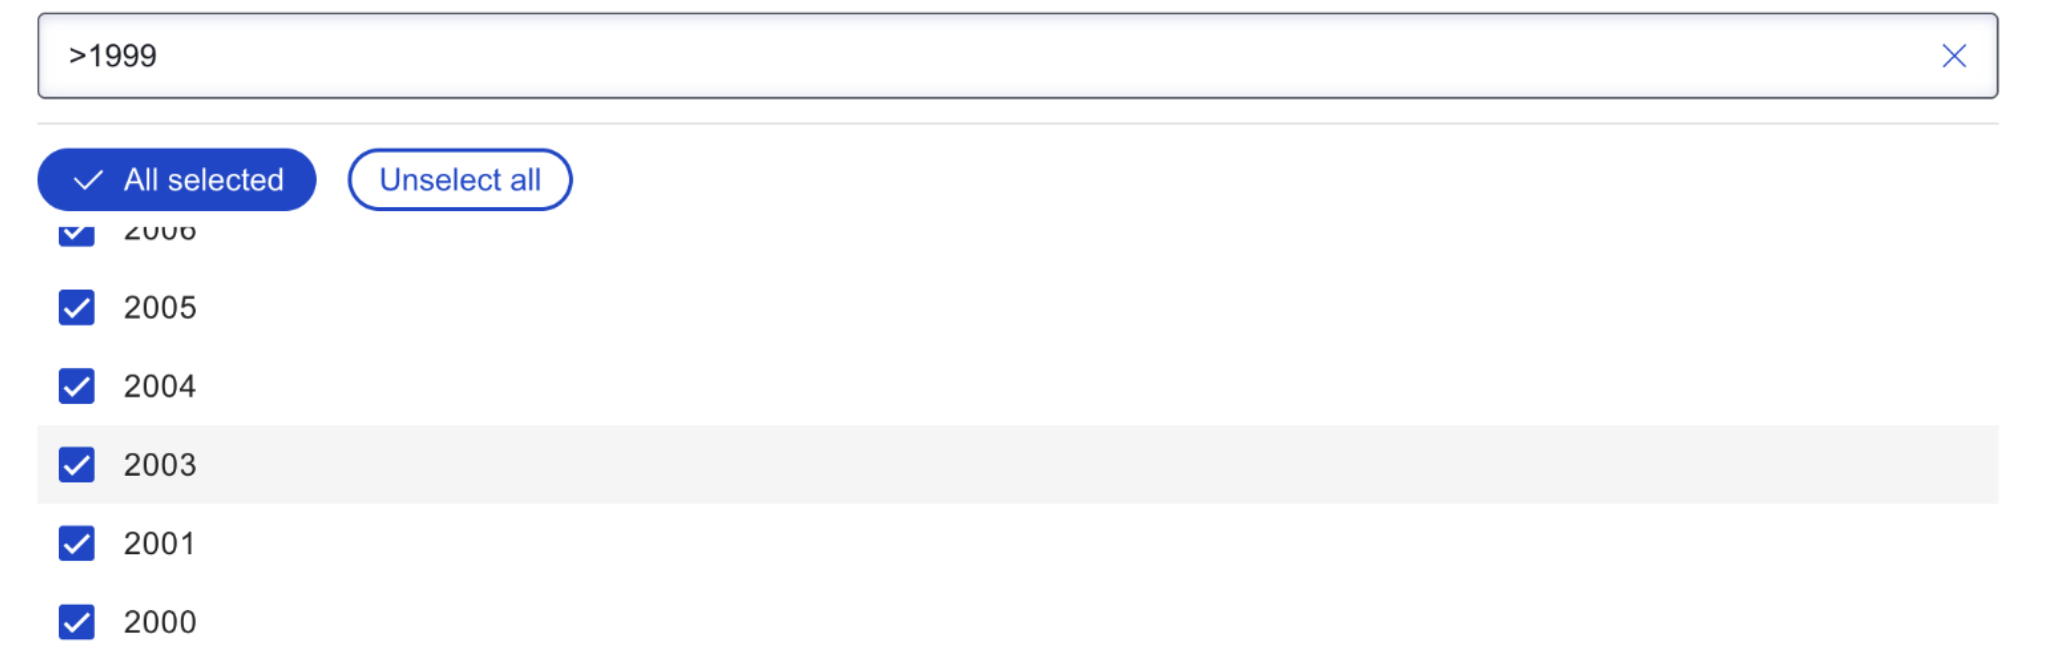

In [11]:
# Check 2 | number of quarters per geo/category for HICP
group_counts = (
    hicp_index_q
    .groupby(["geo", "coicop"])["timeQuarter"]
    .nunique()
)

print(group_counts.describe())
print("Any groups not having 100 quarters?",
      (group_counts != 100).any())


count    468.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
Name: timeQuarter, dtype: float64
Any groups not having 100 quarters? False


In [12]:
group_counts_inf = (
    hicp_inflation_q
    .groupby(["geo", "coicop"])["timeQuarter"]
    .nunique()
)

print(group_counts_inf.describe())
print("Any HICP inflation groups not having 100 quarters?",
      (group_counts_inf != 100).any())


count    468.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
Name: timeQuarter, dtype: float64
Any HICP inflation groups not having 100 quarters? False


In [13]:
group_counts_inc = (
    income_q
    .groupby(["geo", "quantile", "indic_il", "currency"])["timeQuarter"]
    .nunique()
)

print(group_counts_inc.describe())
print("Any income groups not having 96 quarters?",
      (group_counts_inc != 96).any())


count    2016.0
mean       96.0
std         0.0
min        96.0
25%        96.0
50%        96.0
75%        96.0
max        96.0
Name: timeQuarter, dtype: float64
Any income groups not having 96 quarters? False


In [14]:
group_counts_emp = (
    employment_q
    .groupby(["geo", "nace_r2", "na_item"])["timeQuarter"]
    .nunique()
)

print(group_counts_emp.describe())
print("Any employment groups not having 100 quarters?",
      (group_counts_emp != 100).any())


count    432.0
mean     100.0
std        0.0
min      100.0
25%      100.0
50%      100.0
75%      100.0
max      100.0
Name: timeQuarter, dtype: float64
Any employment groups not having 100 quarters? False


In [15]:
# Check 3 | that most quarters have all 3 months
for name, df in [
    ("HICP index", hicp_index_q),
    ("HICP inflation", hicp_inflation_q),
]:
    print(f"\n{name} – nMonths distribution")
    print(df["nMonths"].value_counts().sort_index())


HICP index – nMonths distribution
nMonths
0      754
1       26
2       13
3    46007
Name: count, dtype: Int64

HICP inflation – nMonths distribution
nMonths
0      939
1       53
2       13
3    45795
Name: count, dtype: Int64


In [16]:
# Check 4 | Income sanity: 4× replication
len_income_long = len(income_long)
len_income_q = len(income_q)

print("Income long rows:", len_income_long)
print("Income quarterly rows:", len_income_q)
print("Ratio quarterly/annual:", len_income_q / len_income_long)


Income long rows: 48384
Income quarterly rows: 193536
Ratio quarterly/annual: 4.0


### Creating parquet data_interim files

In [17]:
DATA_INTERIM_DIR.mkdir(parents=True, exist_ok=True)

hicp_index_q_path = DATA_INTERIM_DIR / "hicp_index_quarterly_long.parquet"
hicp_inflation_q_path = DATA_INTERIM_DIR / "hicp_inflation_quarterly_long.parquet"
income_q_path = DATA_INTERIM_DIR / "income_quarterly_long.parquet"
employment_q_path = DATA_INTERIM_DIR / "employment_quarterly_long.parquet"

hicp_index_q.to_parquet(hicp_index_q_path)
hicp_inflation_q.to_parquet(hicp_inflation_q_path)
income_q.to_parquet(income_q_path)
employment_q.to_parquet(employment_q_path)

print("Saved:")
print(hicp_index_q_path)
print(hicp_inflation_q_path)
print(income_q_path)
print(employment_q_path)


Saved:
/Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/data_interim/hicp_index_quarterly_long.parquet
/Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/data_interim/hicp_inflation_quarterly_long.parquet
/Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/data_interim/income_quarterly_long.parquet
/Users/princebhanusteta/Documents/Projects/euro-macro-inflation-income/data_interim/employment_quarterly_long.parquet


In [18]:
test = pd.read_parquet(hicp_index_q_path)
print(test.shape, test.head(2))


(46800, 7)   freq unit coicop geo timeQuarter  hicpIndex  nMonths
0    M  I15   CP00  AT      2000Q1  74.683333        3
1    M  I15   CP00  AT      2000Q2      74.83        3
